# Matriz Catch22

In [12]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

In [13]:
# Toma automaticamente TODOS los csv que el equipo haya guardado en catch22_features/
archivos = glob.glob('../../catch22_features/*.csv')
print(f"Archivos encontrados ({len(archivos)}):")
for a in archivos:
    print(' -', a)

matriz = pd.concat([pd.read_csv(a, index_col=0) for a in archivos])
print(f"\nMatriz: {matriz.shape[0]} series x {matriz.shape[1]} características")
matriz

Archivos encontrados (7):
 - ../../catch22_features/catch22_maritima.csv
 - ../../catch22_features/catch22_valle_nuevo.csv
 - ../../catch22_features/catch22_total.csv
 - ../../catch22_features/catch22_san_cristobal.csv
 - ../../catch22_features/catch22_via_terrestre.csv
 - ../../catch22_features/catch22_via_aerea.csv
 - ../../catch22_features/catch22_la_aurora.csv

Matriz: 7 series x 22 características


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
Marítima,-0.514655,-0.742927,2.449991,6,0.156461,-0.093314,0.641148,26.0,0.007733,11,...,0.200000,0.033333,0.514286,0.725599,5.0,1.908973,0.857143,0.142857,0.515418,0.887796
Valle Nuevo,0.311715,0.074944,9.212324,2,0.265304,-0.091713,0.923445,38.0,0.038567,7,...,0.055556,0.161905,0.328571,0.792308,6.0,1.854340,0.142857,0.833333,0.122718,0.655304
Total,0.188540,-0.580353,8.578892,10,0.453530,-0.126601,0.913876,30.0,0.013774,11,...,0.055556,0.219048,0.323810,0.829129,6.0,1.846797,0.761905,0.857143,0.147262,0.627355
San Cristobal,0.583543,-0.115727,8.496822,7,0.345451,-0.046063,0.870813,31.0,0.069959,7,...,0.047619,0.200000,-0.414286,0.788250,5.0,1.749545,0.142857,0.857143,0.122718,0.693383
Vía Terrestre,-0.547059,-0.781574,8.996925,3,0.537476,-0.087833,0.909091,30.0,0.005510,3,...,0.055556,0.257143,0.309524,0.834162,6.0,1.768209,0.761905,0.833333,0.122718,0.604538
Vía Aérea,-0.407683,-0.122819,6.436692,10,0.207346,-0.174924,0.961722,34.0,0.010204,11,...,0.071429,0.185714,0.323810,0.755889,5.0,1.986657,0.857143,0.857143,0.171806,0.743024
La Aurora,-0.401319,-0.117716,6.601760,10,0.203560,-0.162875,0.947368,34.0,0.010204,11,...,0.071429,0.188095,0.323810,0.758802,5.0,2.000891,0.857143,0.857143,0.171806,0.737701


## Estandarizar

In [14]:
scaler = StandardScaler()
matriz_std = pd.DataFrame(
    scaler.fit_transform(matriz),
    index=matriz.index,
    columns=matriz.columns
)
matriz_std

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
Marítima,-0.942055,-1.241452,-2.168522,-0.273293,-1.166667,0.440730,-2.361937,-1.643950,-0.660430,0.784465,...,2.415984,-2.216249,0.975115,-1.572496,-0.866025,0.388866,0.750934,-2.447328,2.420007,2.046440
Valle Nuevo,0.993331,1.284002,0.884401,-1.548658,-0.338952,0.478680,0.417208,1.724143,0.739586,-0.588348,...,-0.482287,-0.245091,0.304570,0.240830,1.154701,-0.212248,-1.568128,0.343726,-0.558463,-0.585361
Total,0.704851,-0.739448,0.598432,1.002073,1.092446,-0.348461,0.323000,-0.521253,-0.386156,0.784465,...,-0.482287,0.630979,0.287376,1.241717,1.154701,-0.295239,0.441726,0.439969,-0.372309,-0.901743
San Cristobal,1.629962,0.695242,0.561381,0.045549,0.270544,1.560985,-0.100937,-0.240578,2.164909,-0.588348,...,-0.641532,0.338956,-2.377611,0.130517,-0.866025,-1.365280,-1.568128,0.439969,-0.558463,-0.154305
Vía Terrestre,-1.017948,-1.360787,0.787157,-1.229816,1.730828,0.570676,0.275896,-0.521253,-0.761404,-1.961161,...,-0.482287,1.215026,0.235796,1.378521,1.154701,-1.159921,0.441726,0.343726,-0.558463,-1.160027
Vía Aérea,-0.691523,0.673342,-0.368686,1.002073,-0.779703,-1.494136,0.794041,0.601445,-0.548253,0.784465,...,-0.163795,0.119938,0.287376,-0.749145,-0.866025,1.243605,0.750934,0.439969,-0.186154,0.407625
La Aurora,-0.676618,0.689101,-0.294164,1.002073,-0.808496,-1.208474,0.652729,0.601445,-0.548253,0.784465,...,-0.163795,0.156441,0.287376,-0.669943,-0.866025,1.400217,0.750934,0.439969,-0.186154,0.347371


## PCA

Varianza explicada por componente: [0.478 0.22  0.171 0.091 0.039 0.001]
Varianza acumulada (PC1+PC2): 69.8%


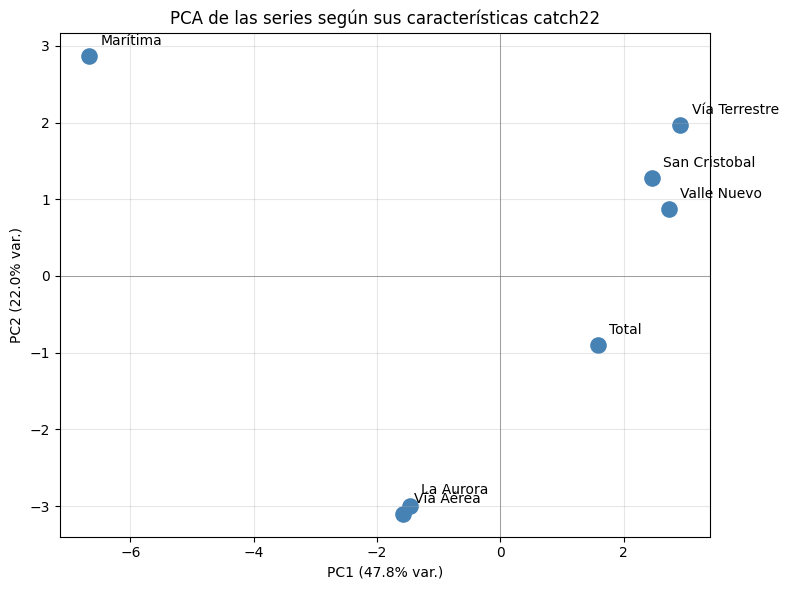

In [15]:
n_series = matriz_std.shape[0]
n_comp = min(n_series - 1, matriz_std.shape[1])  # con pocas series, el maximo de componentes utiles es n_series-1

pca = PCA(n_components=n_comp)
componentes = pca.fit_transform(matriz_std)
df_pca = pd.DataFrame(componentes, index=matriz_std.index,
                       columns=[f'PC{i+1}' for i in range(n_comp)])

print("Varianza explicada por componente:", np.round(pca.explained_variance_ratio_, 3))
print(f"Varianza acumulada (PC1+PC2): {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_pca['PC1'], df_pca['PC2'], s=120, color='steelblue')
for nombre, row in df_pca.iterrows():
    ax.annotate(nombre, (row['PC1'], row['PC2']), textcoords="offset points", xytext=(8, 8))
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.set_title('PCA de las series según sus características catch22')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Clustering

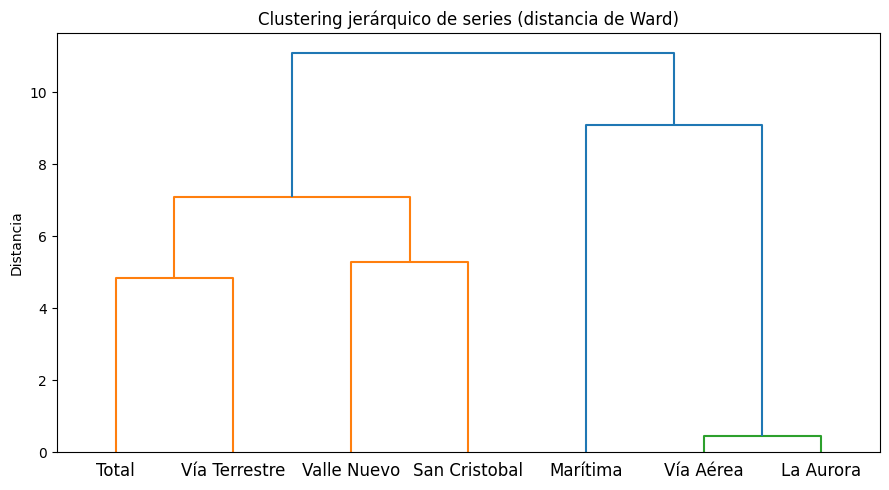

k=2 -> silhouette=0.273
k=3 -> silhouette=0.326
k=4 -> silhouette=0.346
k=5 -> silhouette=0.296

Mejor k según silhouette: 4
serie
Marítima         1
Valle Nuevo      3
Total            0
San Cristobal    3
Vía Terrestre    0
Vía Aérea        2
La Aurora        2
Name: cluster, dtype: int32


In [16]:
# --- Jerarquico: mejor opcion cuando hay pocas series, muestra como se van agrupando ---
Z = linkage(matriz_std, method='ward')
fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(Z, labels=matriz_std.index.tolist(), ax=ax)
ax.set_title('Clustering jerárquico de series (distancia de Ward)')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.show()

# --- KMeans con seleccion de k por silhouette (solo si hay series suficientes) ---
if n_series >= 4:
    mejores = []
    for k in range(2, min(6, n_series)):
        km = KMeans(n_clusters=k, random_state=123, n_init=10)
        labels = km.fit_predict(matriz_std)
        score = silhouette_score(matriz_std, labels)
        mejores.append((k, score))
        print(f"k={k} -> silhouette={score:.3f}")

    mejor_k = max(mejores, key=lambda x: x[1])[0]
    km_final = KMeans(n_clusters=mejor_k, random_state=123, n_init=10)
    matriz_std['cluster'] = km_final.fit_predict(matriz_std)
    print(f"\nMejor k según silhouette: {mejor_k}")
    print(matriz_std['cluster'])
    matriz_std = matriz_std.drop(columns='cluster')
else:
    print(f"Solo hay {n_series} series: con tan pocas, el dendrograma jerárquico de arriba "
          f"es más informativo que KMeans (que necesita más puntos para elegir k con sentido).")

## Heatmap de Características

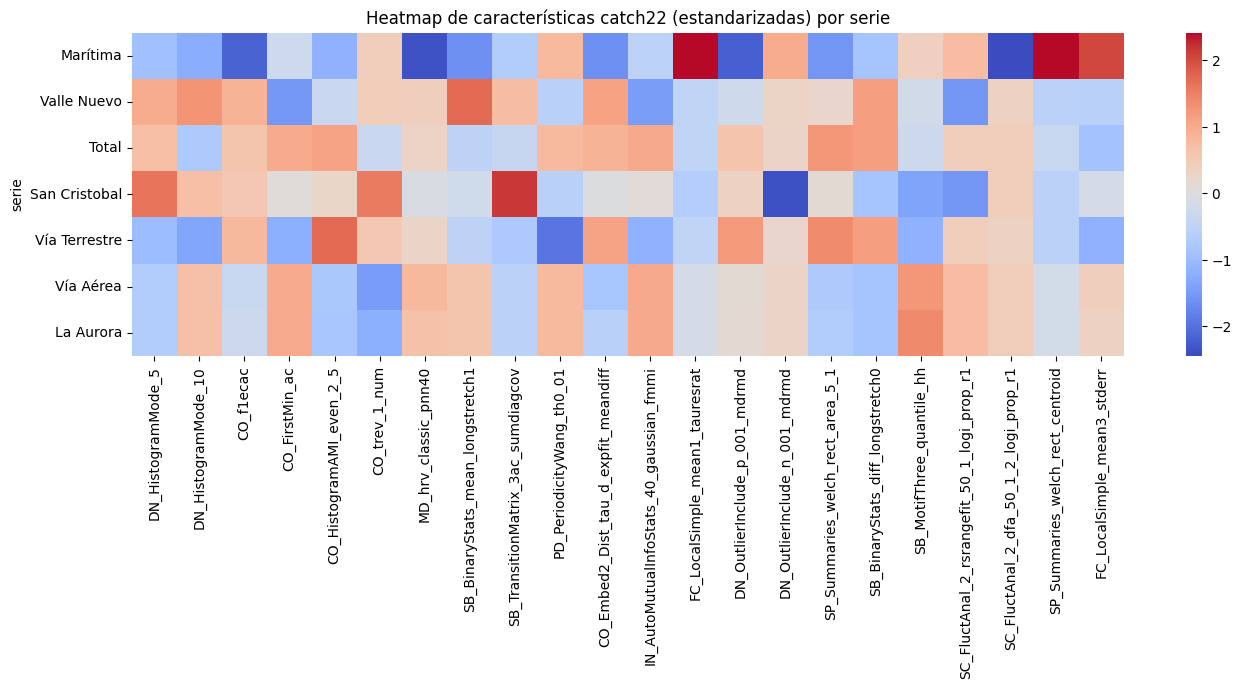

In [17]:
fig, ax = plt.subplots(figsize=(16, max(3, 0.6 * n_series)))
sns.heatmap(matriz_std, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Heatmap de características catch22 (estandarizadas) por serie')

plt.show()

In [18]:
loadings = pd.DataFrame(pca.components_, columns=matriz_std.columns, index=[f'PC{i+1}' for i in range(pca.n_components_)])
print("Top 5 features que más pesan en PC1:")
print(loadings.loc['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop 5 features que más pesan en PC2:")
print(loadings.loc['PC2'].abs().sort_values(ascending=False).head(5))

Top 5 features que más pesan en PC1:
CO_f1ecac                               0.305680
FC_LocalSimple_mean3_stderr             0.293138
CO_Embed2_Dist_tau_d_expfit_meandiff    0.281692
SP_Summaries_welch_rect_centroid        0.280852
FC_LocalSimple_mean1_tauresrat          0.280711
Name: PC1, dtype: float64

Top 5 features que más pesan en PC2:
CO_trev_1_num                              0.394098
IN_AutoMutualInfoStats_40_gaussian_fmmi    0.359871
CO_FirstMin_ac                             0.339509
SB_MotifThree_quantile_hh                  0.320932
MD_hrv_classic_pnn40                       0.315982
Name: PC2, dtype: float64


## Matriz de Correlaciones

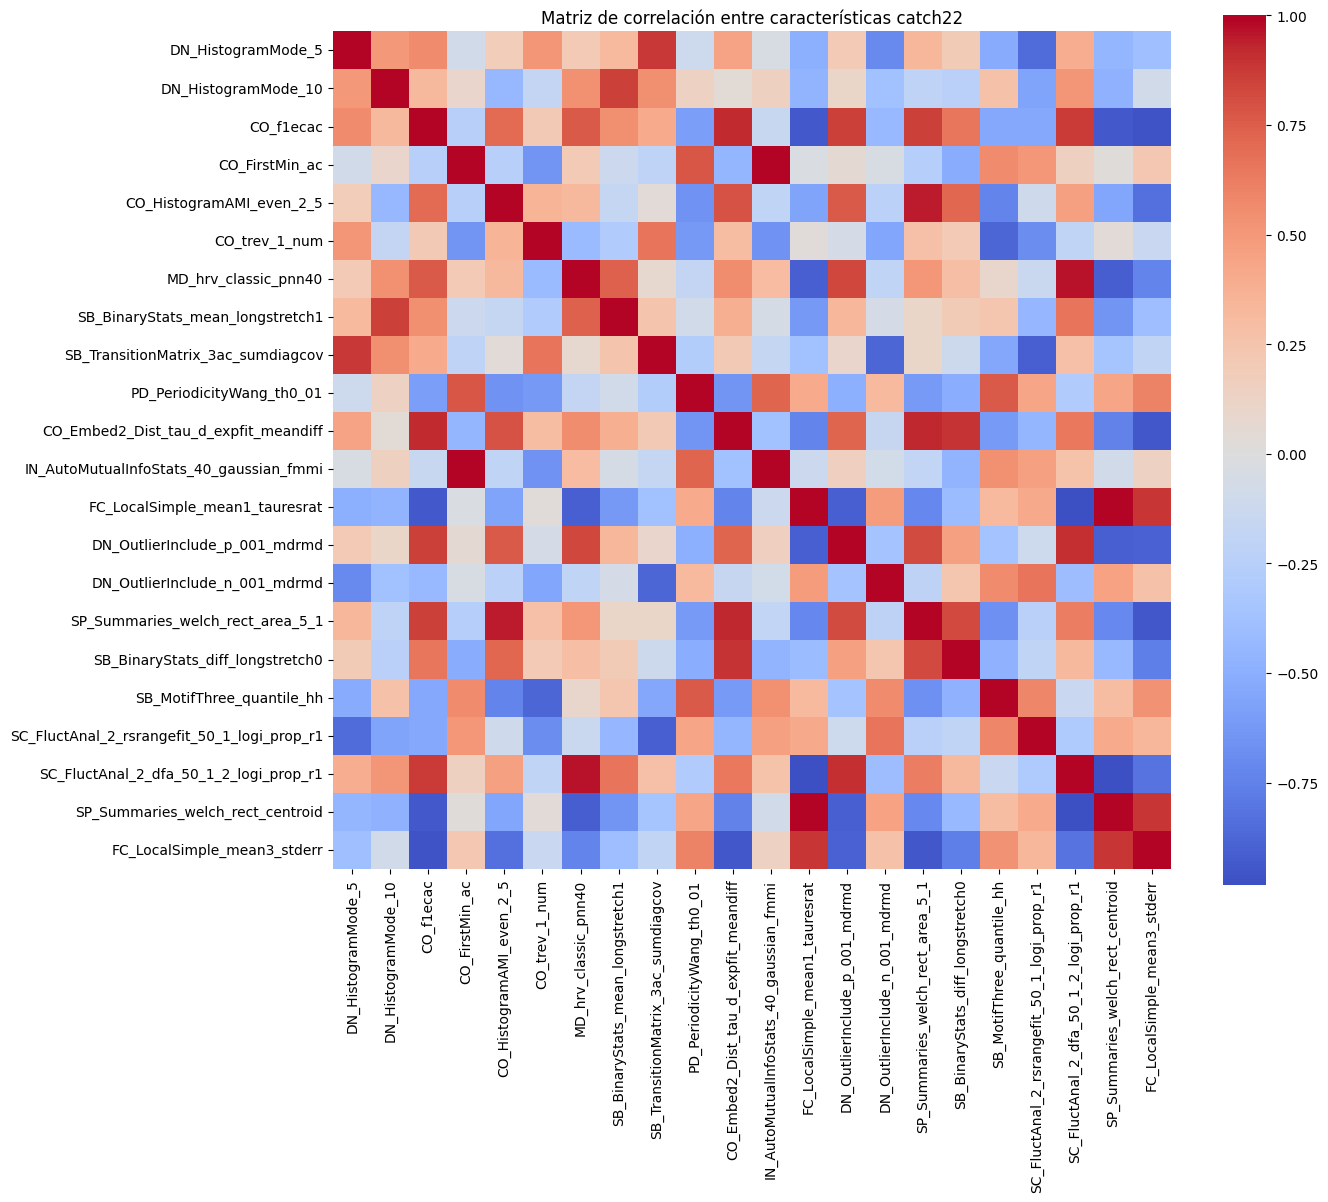

In [19]:
corr = matriz_std.corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True,
            xticklabels=True, yticklabels=True)
ax.set_title('Matriz de correlación entre características catch22')
plt.tight_layout()
plt.show()

## Mapa de Distancias entre Series

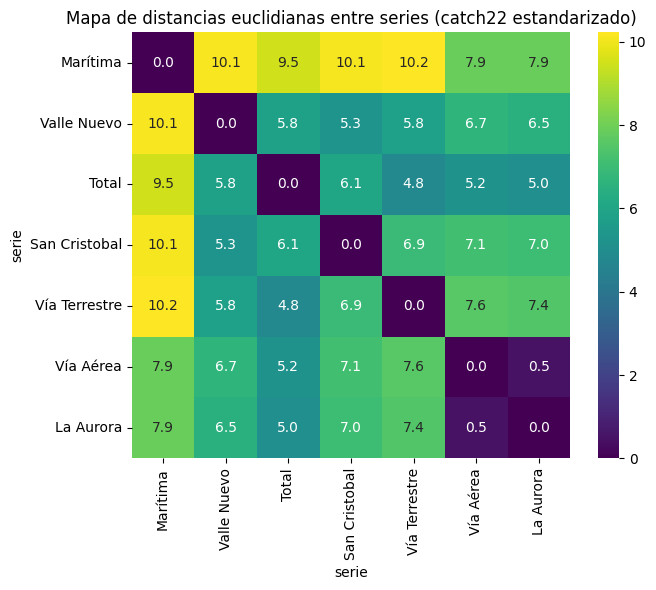

In [20]:
dist_matrix = squareform(pdist(matriz_std, metric='euclidean'))
df_dist = pd.DataFrame(dist_matrix, index=matriz_std.index, columns=matriz_std.index)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_dist, cmap='viridis', annot=True, fmt='.1f', ax=ax)
ax.set_title('Mapa de distancias euclidianas entre series (catch22 estandarizado)')
plt.tight_layout()
plt.show()

In [21]:
matriz_std.to_csv('../../catch22_features/matriz_std.csv')
print("Guardado: ../../catch22_features/matriz_std.csv")

Guardado: ../../catch22_features/matriz_std.csv
